This  notebook generates the figures used in my thesis about fitting a multi-compartment model to real experimental data.

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

In [41]:
best_losses_2 = np.load("../results/multi_2_best_losses.npy")
best_preds_2 = np.load("../results/multi_2_best_preds.npy")
best_losses_4 = np.load("../results/multi_4_best_losses.npy")
best_preds_4 = np.load("../results/multi_4_best_preds.npy")
best_losses_4_new = np.load("../results/multi_4_best_losses_new.npy")
best_preds_4_new = np.load("../results/multi_4_best_preds_new.npy")

v_data = np.load("../results/v_data.npy")
v_data_long = np.load("../results/v_data_long.npy")

time_vec = np.arange(0, 150+2*0.025, 0.025)
time_vec = time_vec[1500:]
time_vec_long = np.arange(0, 250+2*0.025, 0.025)
time_vec_long = time_vec_long[1500:]

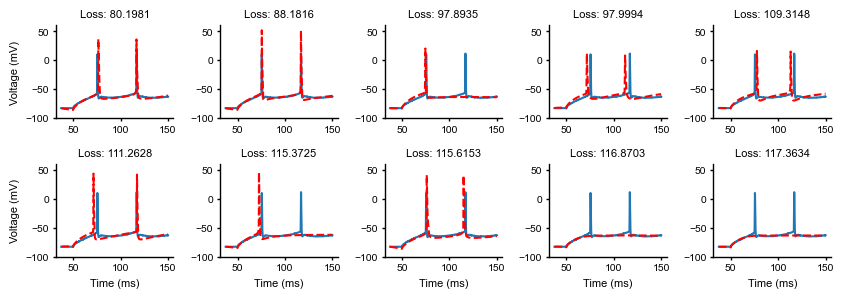

In [42]:
inds = np.argsort(best_losses_2)

with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,5, figsize = (10,3))
    fig.subplots_adjust(wspace=0.4)
    fig.subplots_adjust(hspace=0.5)
    
    for i in range(2):
        for j in range(5):
            axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=1.5)
            axs[i,j].plot(time_vec, best_preds_2[i*5+j], label="Multi-compartment prediction", linestyle="--", linewidth=1.5, color = 'r')
            axs[i,j].set_title(f"Loss: {best_losses_2[i*5+j]:.4f}", fontsize = 8)
            axs[i,j].set_ylim(-100, 60)

    for j in range(5):
        axs[1,j].set_xlabel("Time (ms)", fontsize=8)
    for i in range(2):
        axs[i,0].set_ylabel("Voltage (mV)", fontsize=8)

    fig.savefig("../svg/multi_150.svg", bbox_inches='tight', dpi = 300)

    plt.show()

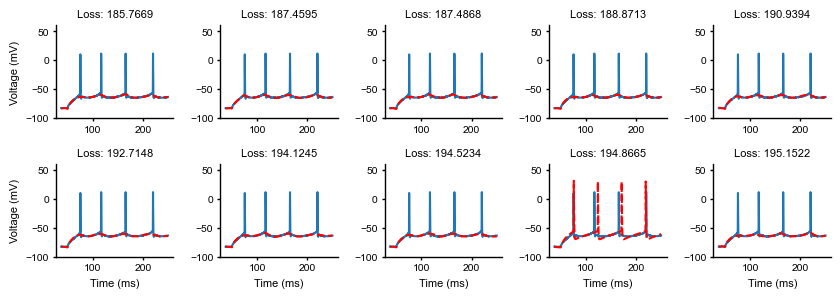

In [43]:
inds = np.argsort(best_losses_4)

with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,5, figsize = (10,3))
    fig.subplots_adjust(wspace=0.4)
    fig.subplots_adjust(hspace=0.5)
    
    for i in range(2):
        for j in range(5):
            axs[i,j].plot(time_vec_long, v_data_long[0], label="Experimental target", linewidth=1.5)
            axs[i,j].plot(time_vec_long, best_preds_4[i*5+j], label="Multi-compartment prediction", linestyle="--", linewidth=1.5, color = 'red')
            axs[i,j].set_title(f"Loss: {best_losses_4[i*5+j]:.4f}", fontsize = 8)
            axs[i,j].set_ylim(-100, 60)

    for j in range(5):
        axs[1,j].set_xlabel("Time (ms)", fontsize=8)
    for i in range(2):
        axs[i,0].set_ylabel("Voltage (mV)", fontsize=8)

    fig.savefig("../svg/multi_250.svg", bbox_inches='tight', dpi = 300)

    plt.show()

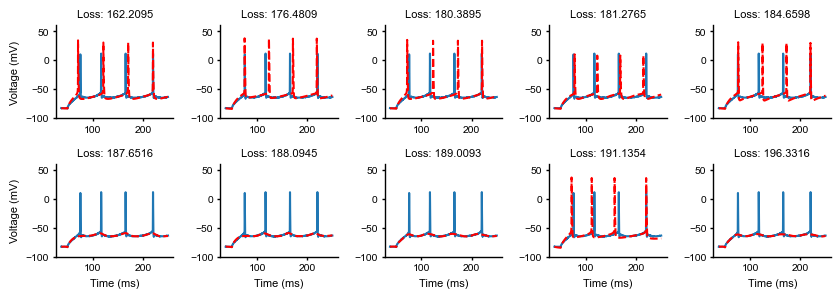

In [44]:
inds = np.argsort(best_losses_4_new)

with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,5, figsize = (10,3))
    fig.subplots_adjust(wspace=0.4)
    fig.subplots_adjust(hspace=0.5)
    
    for i in range(2):
        for j in range(5):
            axs[i,j].plot(time_vec_long, v_data_long[0], label="Experimental target", linewidth=1.5)
            axs[i,j].plot(time_vec_long, best_preds_4_new[i*5+j], label="Multi-compartment prediction", linestyle="--", linewidth=1.5, color = 'red')
            axs[i,j].set_title(f"Loss: {best_losses_4_new[i*5+j]:.4f}", fontsize = 8)
            axs[i,j].set_ylim(-100, 60)

    for j in range(5):
        axs[1,j].set_xlabel("Time (ms)", fontsize=8)
    for i in range(2):
        axs[i,0].set_ylabel("Voltage (mV)", fontsize=8)

    fig.savefig("../svg/multi_250_2.svg", bbox_inches='tight', dpi = 300)

    plt.show()

In [34]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("23.2cm", "12.9cm",
           
    Panel(
          SVG("../svg/optimized_parameters_2.svg").scale(svg_scale),
        #   Text("a", 10, 12.0, **kwargs_text),
    ).move(0, 0),
    Panel(
          SVG("../svg/optimized_parameters_4.svg").scale(svg_scale),
        #   Text("b", 10, 12.0, **kwargs_text),
    ).move(500, 0),

)

#!mkdir -p fig
f.save("../fig/multi_optimized_params.svg")
svg("../fig/multi_optimized_params.svg")

In [ ]:
f = Figure("20.1cm", "7.2cm",
           
    Panel(
          SVG("../svg/multi_150.svg").scale(svg_scale),
    ).move(0, 0),
)

#!mkdir -p fig
f.save("../fig/multi_150.svg")
svg("../fig/multi_150.svg")

In [48]:
f = Figure("20.1cm", "14.6cm",
           
    Panel(
          SVG("../svg/multi_250.svg").scale(svg_scale),
          Text("a", 10, 12.0, **kwargs_text),
    ).move(0, 0),
    Line([(0, 272), (1000, 272)], width=1.5, color="black"),

    Panel(
          SVG("../svg/multi_250_2.svg").scale(svg_scale),
          Text("b", 10, 12.0, **kwargs_text),
    ).move(0, 280),

)

#!mkdir -p fig
f.save("../fig/multi_250.svg")
svg("../fig/multi_250.svg")